In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_wine
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from sklearn.cluster import SpectralClustering, AffinityPropagation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, Birch, SpectralClustering, AffinityPropagation, OPTICS
from sklearn.mixture import GaussianMixture
from hdbscan import HDBSCAN
from sklearn.ensemble import IsolationForest
from minisom import MiniSom
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
import threading
from sklearn.base import clone
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import warnings
from deap import base, creator, tools, algorithms
plt.rcParams['figure.dpi'] = 100#1200
with warnings.catch_warnings():
    warnings.simplefilter("ignore")



In [2]:
# Load data
df_base = pd.read_csv('./cicids_2017_profiles_new.csv', header=0)
white_list=["172.16.0.1", #Firewall
            "192.168.10.3",#DNS+ DC Server
            "192.168.10.1"#GateWay
           
           ]

df_base = df_base[~df_base['ip_src'].isin(white_list)]

all_ips = df_base.iloc[:, 31]
#print("ISX 2014 Profile Count:", len(all_ips))
#print("ISX 2014 Raw Log Count: 14,502,784")
print("CIC-IDS 2017 Profile Count:", len(all_ips))
print("CIC-IDS 2017 Raw Log Count: 55,066,444")
kmeans_cluster_count = 3
df_base.isnull().values.any()
df_base.fillna(0, inplace=True)
df_base=df_base.loc[:, (df_base != 0).any(axis=0)]

my_data = df_base.drop(["ReqTime", "ip_src", "RowNo"], axis=1)

cluster_count=3

CIC-IDS 2017 Profile Count: 18484
CIC-IDS 2017 Raw Log Count: 55,066,444


In [3]:
all_ips=list(set(df_base["ip_src"]))
#private ips
infected_ips = [
"192.168.10.50",
"192.168.10.51",
"192.168.10.19",
"192.168.10.17",
"192.168.10.16",
"192.168.10.12",
"192.168.10.9",
"192.168.10.5",
"192.168.10.8",
"192.168.10.14",
"192.168.10.15",
"192.168.10.25"]
infected_ips = [itm for itm in infected_ips if itm in all_ips]
print("infected_ips:")
print(len(infected_ips))


infected_ips:
12


In [4]:
my_data.describe()

,P1_rph,P2_unique_dns_req,P3_domain_rph,P4_avg_rpm,P5_high_req,P6_mx,P7_ptr,P9_TDL,P10_SDL,P11_unique_ratio,...,P20_SSH_ratio,P21_MQTT_ratio,P22_TFTP_ratio,P23_NBNS_ratio,P24_TCP_ratio,P25_DCERPC_ratio,P26_ICMP_ratio,P27_DHCP_ratio,P28_UNIQUEDST_count,P29_DST_count
count,1.848400e+04,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,...,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,1.848400e+04
mean,2.591303e+03,6.362043,0.760874,1.305399,0.199794,0.095109,4.094893,3.530188,7.720353,0.001296,...,0.001020,0.000132,0.000245,0.000410,0.606584,0.000012,0.000012,0.000236,9.425124,2.591303e+03
std,4.287750e+04,52.943773,8.948998,10.831659,5.111171,7.099409,62.730565,26.219193,58.530851,0.134217,...,0.009026,0.008412,0.006493,0.006940,0.256210,0.000236,0.000236,0.005685,52.436811,4.287750e+04
min,1.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.010000e+02
25%,1.490000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.485565,0.000000,0.000000,0.000000,1.000000,1.490000e+02
50%,2.570000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.656863,0.000000,0.000000,0.000000,1.000000,2.570000e+02
75%,5.880000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.792093,0.000000,0.000000,0.000000,4.000000,5.880000e+02
max,2.611693e+06,1039.000000,482.000000,302.000000,596.000000,824.000000,2668.000000,415.000000,1039.000000,17.375000,...,0.389289,1.000000,0.344681,0.304225,1.000000,0.012723,0.012723,0.416887,977.000000,2.611693e+06


In [5]:
corr = my_data.corr()
#print(corr)


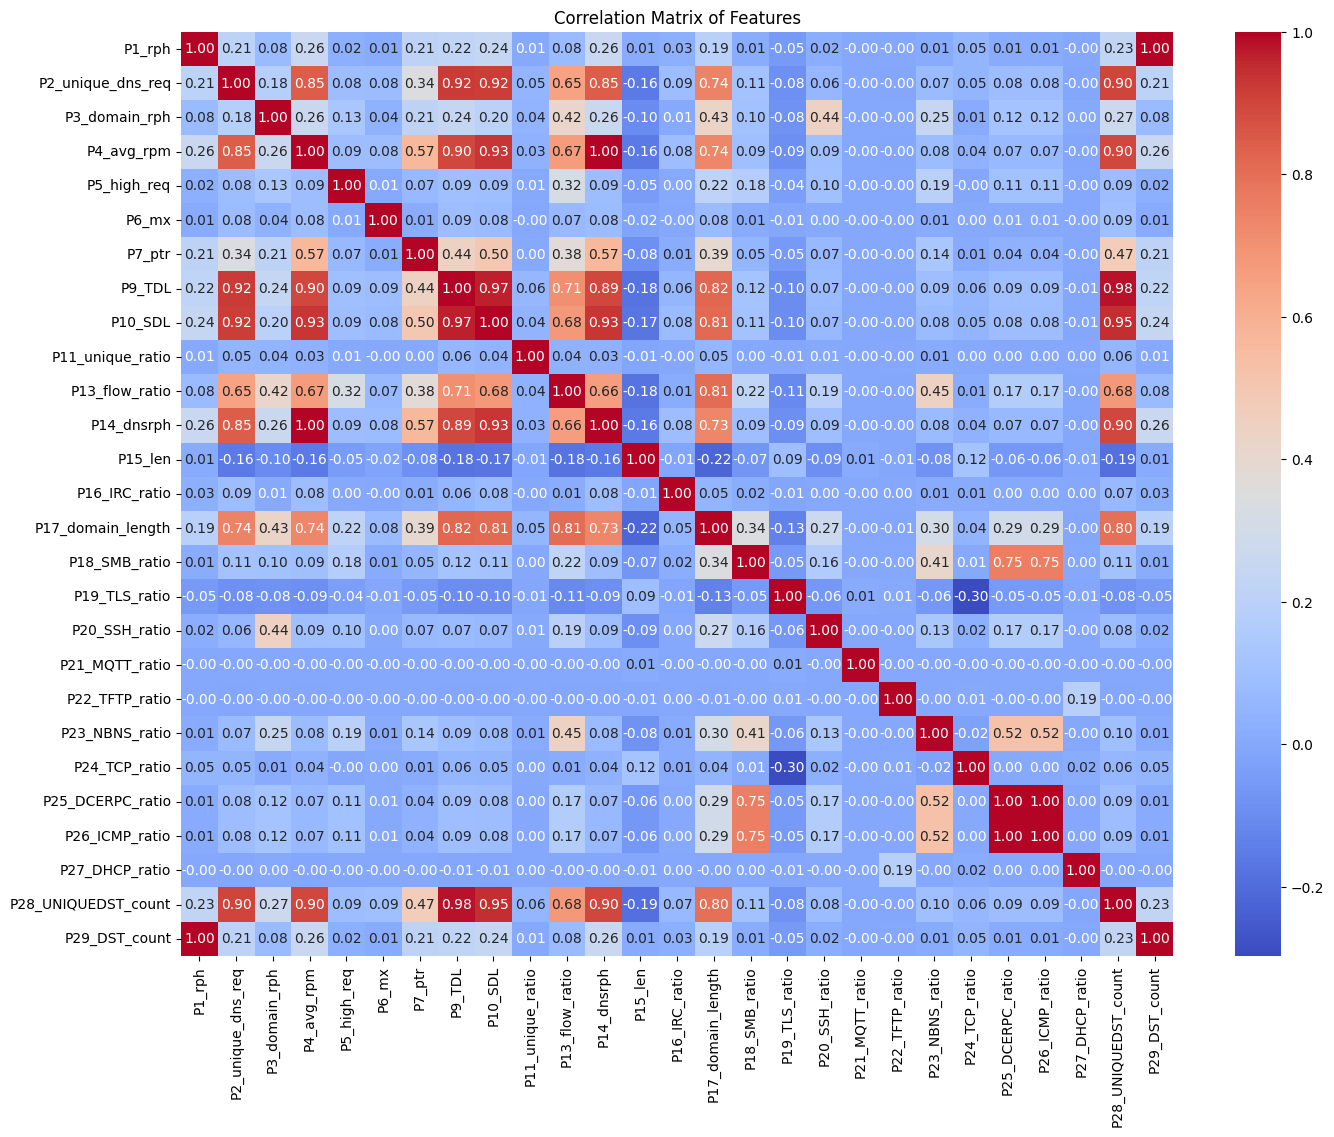

In [6]:

# Plot heatmap of the correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.show()

In [7]:
# Remove features with high correlation 
threshold = 0.9
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
my_data = my_data.drop(to_drop, axis=1)
print("Removed Features:",to_drop)
cols=list(my_data)

Removed Features: ['P9_TDL', 'P10_SDL', 'P14_dnsrph', 'P26_ICMP_ratio', 'P28_UNIQUEDST_count', 'P29_DST_count']


In [8]:
my_data.describe()

,P1_rph,P2_unique_dns_req,P3_domain_rph,P4_avg_rpm,P5_high_req,P6_mx,P7_ptr,P11_unique_ratio,P13_flow_ratio,P15_len,...,P17_domain_length,P18_SMB_ratio,P19_TLS_ratio,P20_SSH_ratio,P21_MQTT_ratio,P22_TFTP_ratio,P23_NBNS_ratio,P24_TCP_ratio,P25_DCERPC_ratio,P27_DHCP_ratio
count,1.848400e+04,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,...,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000
mean,2.591303e+03,6.362043,0.760874,1.305399,0.199794,0.095109,4.094893,0.001296,0.002855,873.495707,...,0.557485,0.000095,0.278840,0.001020,0.000132,0.000245,0.000410,0.606584,0.000012,0.000236
std,4.287750e+04,52.943773,8.948998,10.831659,5.111171,7.099409,62.730565,0.134217,0.020713,572.608501,...,3.327055,0.001696,0.209072,0.009026,0.008412,0.006493,0.006940,0.256210,0.000236,0.005685
min,1.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.490000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,355.597652,...,0.000000,0.000000,0.106434,0.000000,0.000000,0.000000,0.000000,0.485565,0.000000,0.000000
50%,2.570000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,797.667930,...,0.000000,0.000000,0.267974,0.000000,0.000000,0.000000,0.000000,0.656863,0.000000,0.000000
75%,5.880000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1345.696861,...,0.000000,0.000000,0.437874,0.000000,0.000000,0.000000,0.000000,0.792093,0.000000,0.000000
max,2.611693e+06,1039.000000,482.000000,302.000000,596.000000,824.000000,2668.000000,17.375000,0.678977,3526.574884,...,31.500000,0.099379,1.000000,0.389289,1.000000,0.344681,0.304225,1.000000,0.012723,0.416887


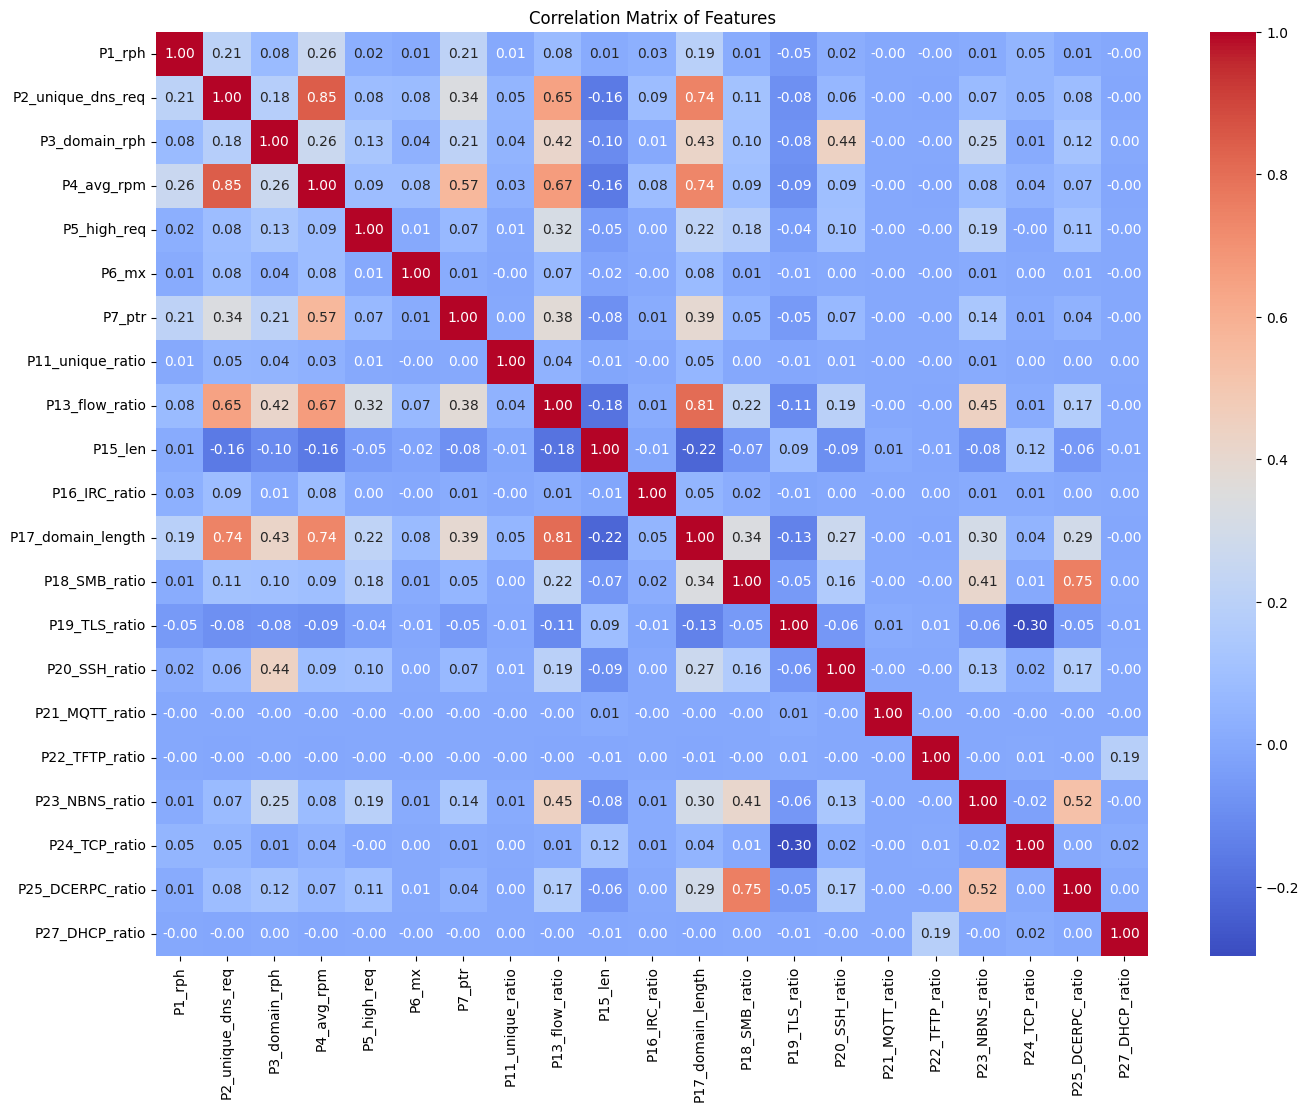

In [9]:
corr = my_data.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.show()

In [10]:

# Inspect the dataframe
print(my_data.columns)
print(my_data.head())


Index(['P1_rph', 'P2_unique_dns_req', 'P3_domain_rph', 'P4_avg_rpm',
       'P5_high_req', 'P6_mx', 'P7_ptr', 'P11_unique_ratio', 'P13_flow_ratio',
       'P15_len', 'P16_IRC_ratio', 'P17_domain_length', 'P18_SMB_ratio',
       'P19_TLS_ratio', 'P20_SSH_ratio', 'P21_MQTT_ratio', 'P22_TFTP_ratio',
       'P23_NBNS_ratio', 'P24_TCP_ratio', 'P25_DCERPC_ratio',
       'P27_DHCP_ratio'],
      dtype='object')
   P1_rph  P2_unique_dns_req  P3_domain_rph  P4_avg_rpm  P5_high_req  P6_mx  \
0     524                  0              0           0            0      0   
1     547                  0              0           0            0      0   
2     544                  0              0           0            0      0   
3     433                  0              0           0            0      0   
4    2318                  0              0           0            0      0   

   P7_ptr  P11_unique_ratio  P13_flow_ratio      P15_len  ...  \
0       0               0.0             0.0  1884.12

In [11]:
# Data preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(my_data)
scaled_df = pd.DataFrame(X_scaled, columns=my_data.columns)


In [12]:
my_data.isnull().values.any()

False

In [13]:

my_data.head(2)

,P1_rph,P2_unique_dns_req,P3_domain_rph,P4_avg_rpm,P5_high_req,P6_mx,P7_ptr,P11_unique_ratio,P13_flow_ratio,P15_len,...,P17_domain_length,P18_SMB_ratio,P19_TLS_ratio,P20_SSH_ratio,P21_MQTT_ratio,P22_TFTP_ratio,P23_NBNS_ratio,P24_TCP_ratio,P25_DCERPC_ratio,P27_DHCP_ratio
0,524,0,0,0,0,0,0,0.0,0.0,1884.120229,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.980916,0.0,0.0
1,547,0,0,0,0,0,0,0.0,0.0,1877.811700,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [14]:
X=scaled_df.values


In [15]:
from sklearn.model_selection import GridSearchCV

pca = PCA(0.95)
X_pca = pca.fit_transform(X_scaled) 
reduced_X=pd.DataFrame(data=pca.fit_transform(X_pca))

reduced_X.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-0.394946,-0.048227,2.203564,-0.419352,-0.304503,0.474671,-0.592012,0.059255,-0.136016,0.303020,0.634109,-0.656819,-0.025926,0.204972,-0.152511,-0.522563
1,-0.489134,0.107260,-0.539668,-0.089512,-0.117895,0.524795,-0.235957,-0.023719,-0.125738,0.221935,0.326886,-0.016356,0.044966,0.638784,-1.047312,-2.825840
2,-0.399557,-0.050237,2.249784,-0.431833,-0.309758,0.499664,-0.611916,0.062924,-0.140048,0.318601,0.656537,-0.683435,-0.026534,0.200280,-0.147119,-0.508095
3,-0.390919,-0.050628,2.246553,-0.421088,-0.306465,0.461370,-0.591554,0.059632,-0.134362,0.297676,0.631561,-0.661131,-0.027285,0.197224,-0.133561,-0.475644
4,-0.248185,-0.058693,1.978363,-0.236064,-0.239201,-0.112481,-0.225015,-0.004444,-0.045351,-0.036530,0.186290,-0.187799,-0.034532,0.171748,-0.010934,-0.127650


In [16]:
# component_df=pd.DataFrame(pca.components_,index=reduced_X.columns)
# # Heat map
# sns.pairplot(component_df)
# plt.suptitle('Pairplot of Principal Components', y=1.02)
# plt.show()

In [17]:
param_grids = {
    'KMeans': {'n_clusters': [2, 3, 4, 5, 6]},
    'AgglomerativeClustering': {'n_clusters': [2, 3, 4, 5, 6]},
   'DBSCAN': {'eps': [0.3, 0.5, 0.7], 'min_samples': [3, 5, 10]},
    'GaussianMixture': {'n_components': [2, 3, 4, 5, 6], 'covariance_type': ['full', 'tied', 'diag', 'spherical']},
   'Birch': {'n_clusters': [2, 3, 4, 5, 6]},
   'MeanShift': {'bandwidth': [1, 2, 3]},
   'SpectralClustering': {'n_clusters': [2, 3, 4, 5, 6], 'affinity': ['nearest_neighbors', 'rbf']}, #graph
   'AffinityPropagation': {'damping': [0.5, 0.6, 0.7, 0.8, 0.9]}, #graph
   'HDBSCAN': {'min_cluster_size': [5, 10, 15]},
   'OPTICS': {'min_samples': [5, 10, 15], 'xi': [0.01, 0.05, 0.1], 'min_cluster_size': [0.05, 0.1, 0.2]},
}

# Define clustering models
models = {
    'KMeans': KMeans(random_state=0),
 # 'AgglomerativeClustering': AgglomerativeClustering(),
 #  'DBSCAN': DBSCAN(),
 #   'GaussianMixture': GaussianMixture(random_state=0),
 #  'Birch': Birch(),
#   'MeanShift': MeanShift(),
    ##'SpectralClustering': SpectralClustering(random_state=0),
    ##'AffinityPropagation': AffinityPropagation(),
   'HDBSCAN': HDBSCAN(),
 #  'OPTICS': OPTICS(),
}

In [18]:
import ipaddress
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix


def is_private_ip(ip):
    return True
    try:
        ip_obj = ipaddress.ip_address(ip)
        return ip_obj.is_private
    except ValueError:
        return False 

In [19]:
def get_memory_usage():
    process = psutil.Process(os.getpid())
    memory_info = process.memory_info()
    return memory_info.rss / (1024 * 1024)  # Memory usage in MB


In [20]:
# Calculate ROC AUC for each model
import time
import os
import psutil  # For measuring CPU time and utilization

def calculate_roc_auc(f_parameters):



  model,params, X, y_true=f_parameters
  model.set_params(**params)
  try:
    start_memory = get_memory_usage()
    start_time = time.time()  # Start time for wall-clock time
    start_cpu_time = psutil.cpu_times()  # Start CPU time
    model.fit(X)
    if hasattr(model, 'labels_'):
        y_pred = model.labels_
    else:
        y_pred = model.predict(X)
    clusters = {}
    n = 0
    for item in y_pred:
        if item in clusters:
            clusters[item].append(df_base.iloc[n]['ip_src'])
        else:
            clusters[item] = [df_base.iloc[n]['ip_src']]
        
        n +=1
    normal_cluster=0
    predicted_labels=[]
    
    for item in clusters:
        if(len(clusters[item])>len(clusters[normal_cluster])):
            normal_cluster=item
        
        # print ("Cluster ", item,' Count: ',len(clusters[item]),' DCCount: ',len(list(set(clusters[item]))))
        # print("Count: ",len(list(set(clusters[item]))))
     #   print("Data: \n",(list(set(clusters[item]))),"\n\n")
        if(item>0):
            for i in clusters[item]:
                 predicted_labels.append(i)
    # print("Normal Cluster index: ",normal_cluster)
    # برچسب‌های خوشه (تخمین زده شده)
    bad_items=[]
    for item in clusters:
        if(item!=normal_cluster):
            for bd_item in list(set(clusters[item])):
                bad_items.append(bd_item)



      
    y_true = []
    
    y_scores = []
    FP = []
    FN = []
    TP = []
    TN = []
    
    
    detected_ips = bad_items
    
    
    for ip in all_ips:
      if is_private_ip(ip):
        if ip in infected_ips :
            y_true.append(1)  # آلوده
        else:
            y_true.append(0)  # عادی
    
        
        if ip in detected_ips :
            #print(ip)
            y_scores.append(1)  # آلوده
        else:
            y_scores.append(0)  # عادی
    
        if not(ip in infected_ips) and (ip in detected_ips) :
            FP.append(ip) 
            #print("over detected (FP):",str(ip))
        if (ip in infected_ips) and not(ip in detected_ips)  :
            FN.append(ip) 
           # print("not detected (FN):",str(ip))
        if  (ip in infected_ips) and (ip in detected_ips):
            TP.append(ip) 
        if not(ip in infected_ips) and not(ip in detected_ips) :
            TN.append(ip) 
      else:
        TN.append(ip)
        y_true.append(0)  # عادی
        y_scores.append(0)  # عادی
    y_scores=np.array(y_scores)
    y_true=np.array(y_true)
  #  print("Infected:" ,len(infected_ips))
   # print("Detected:" ,len(bad_items))
   # print("FP Count:" ,len(FP))
   # print("FN Count:" ,len(FN))
   # print("TP Count:" ,len(TP))
   # print("TN Count:" ,len(TN))
   # print("Distinct IP Count:" ,len(all_ips))
    auroc = roc_auc_score(np.array(y_true),np.array( y_scores))
   # print("TP Count:" ,len(TP))
   # print("FP Count:" ,len(FP))
   # print("---------------------------------------")

    end_time = time.time()  # End time for wall-clock time
    end_cpu_time = psutil.cpu_times()  # End CPU time
    end_memory = get_memory_usage() 
    memory_usage = end_memory - start_memory 
    execution_time = end_time - start_time  # Total execution time in seconds
    cpu_time_user = end_cpu_time.user - start_cpu_time.user  # User CPU time
    cpu_time_system = end_cpu_time.system - start_cpu_time.system  # System CPU time
 
    print("####Model::::",model,"@@@@AUROC: ", round(auroc,4)," Time: ",execution_time)


    return auroc, y_scores, y_true,y_pred,FP,params,execution_time,cpu_time_user,cpu_time_system,memory_usage,model
  except Exception as e:
        print(f"Error in my_function: {e}")
        return 0, 0, 0,0,0,0,0,0,0,0,model
def run_multiprocessing(f_parameters):
    model,params, X, y_true=f_parameters
    func_params = [(model, params, X_pca, my_data[cols]) for params in params_list]
    pool = multiprocessing.Pool(multiprocessing.cpu_count()*3)
    res = pool.map(calculate_roc_auc, func_params)

    pool.close()
    pool.join()
    return res
    
    

In [21]:
print("Models Count: ",str(len(models)))

Models Count:  2


####Model:::: KMeans(n_clusters=3, random_state=0) @@@@AUROC:  0.9997  Time:  3.4591517448425293
####Model:::: KMeans(n_clusters=2, random_state=0) @@@@AUROC:  1.0  Time:  3.7070229053497314
####Model::::####Model::::  KMeans(n_clusters=4, random_state=0)KMeans(n_clusters=5, random_state=0)  @@@@AUROC:  @@@@AUROC: 0.6614 0.7316   Time:  Time:  ####Model:::: 4.6699995994567874.592182397842407 

KMeans(n_clusters=6, random_state=0) @@@@AUROC:  0.6606  Time:  4.450089931488037
KMeans Best Params: {'n_clusters': 2} AUROC: 1.0  execution_time: 4.450089931488037S cpu_time_user: 21.829999999841675S  cpu_time_system: 0.9600000000209548S memory_usage: 22.84765625MB
KMeans FP:  []


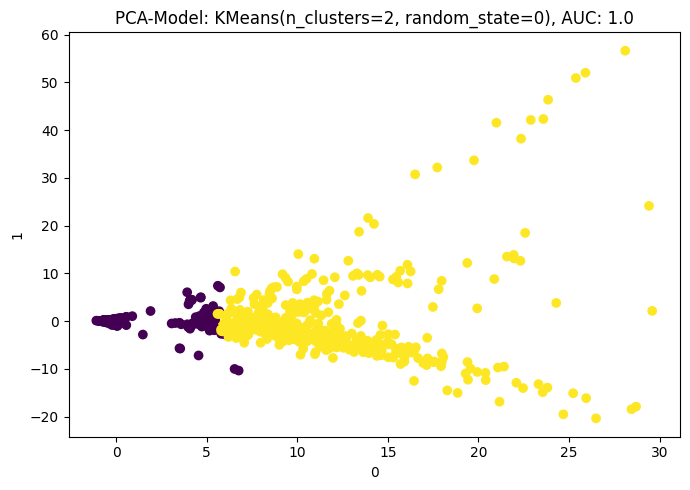

/usr/local/lib/python3.11/dist-packages/joblib/parallel.py:1359: UserWarning: Loky-backed parallel loops cannot be called in a multiprocessing, setting n_jobs=1
  n_jobs = self._backend.configure(n_jobs=self.n_jobs, parallel=self,
/usr/local/lib/python3.11/dist-packages/joblib/parallel.py:1359: UserWarning: Loky-backed parallel loops cannot be called in a multiprocessing, setting n_jobs=1
  n_jobs = self._backend.configure(n_jobs=self.n_jobs, parallel=self,
/usr/local/lib/python3.11/dist-packages/joblib/parallel.py:1359: UserWarning: Loky-backed parallel loops cannot be called in a multiprocessing, setting n_jobs=1
  n_jobs = self._backend.configure(n_jobs=self.n_jobs, parallel=self,


####Model:::: HDBSCAN(min_cluster_size=10) @@@@AUROC:  0.8122  Time:  6.971235513687134
####Model:::: HDBSCAN(min_cluster_size=15) @@@@AUROC:  0.8143  Time:  7.070892333984375
####Model:::: HDBSCAN() @@@@AUROC:  0.6647  Time:  8.602343559265137
HDBSCAN Best Params: {'min_cluster_size': 15} AUROC: 0.8143010560229104  execution_time: 7.070892333984375S cpu_time_user: 21.260000000009313S  cpu_time_system: 0.6699999999837019S memory_usage: 17.0703125MB
HDBSCAN FP:  ['52.21.113.142', '185.86.137.43', '52.72.148.164', '23.208.96.93', '165.224.212.35', '166.78.109.115', '216.58.218.228', '104.25.186.115', '192.229.163.180', '54.209.102.237', '67.72.99.137', '172.217.10.36', '23.208.71.202', '77.158.24.250', '93.158.134.90', '14.0.67.53', '158.85.42.53', '63.251.109.88', '54.183.252.153', '54.243.242.36', '104.16.84.55', '43.253.238.186', '52.84.145.42', '208.111.171.216', '213.19.161.155', '116.62.80.182', '185.13.208.24', '54.209.21.183', '151.101.45.209', '60.199.243.53', '69.90.153.133', '

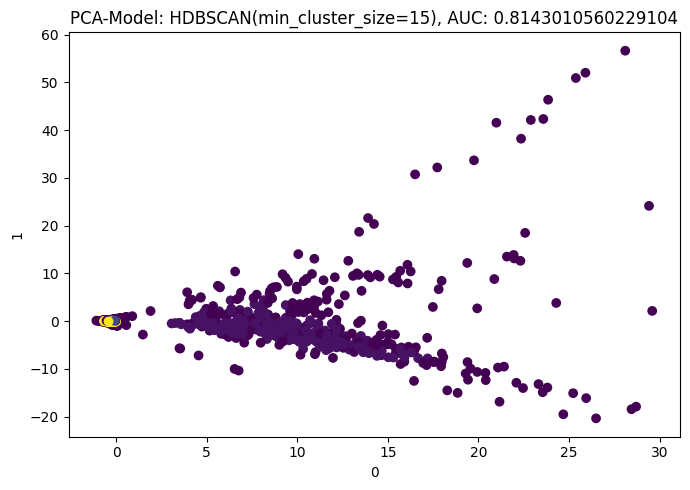

In [22]:
import multiprocessing
roc_auc_scores = {}
best_models = {}
 

import time
import psutil
for name, model in models.items():

    best_auc = 0
    best_model = None
    best_params = None
    best_y_pred = None
    best_FP = None
    best_execution_time = 9999999

    best_mem = None
    best_cpu_time_user=None
    best_cpu_time_system=None
    
    params_list = ParameterGrid(param_grids[name])

    
    results_array = run_multiprocessing([model, param_grids[name], X_pca, my_data[cols]])

    
    for index, result in enumerate(results_array):
         
         auroc, y_scores, y_true,y_pred,FP,params,execution_time,cpu_time_user,cpu_time_system,memory_usage,m_model=result
         if auroc >= best_auc :
            best_auc = auroc
            best_model = clone(m_model)
            best_params = params
            best_y_pred = y_pred
            best_y_true = y_true
            best_y_scores= y_scores
            best_FP=FP
            best_execution_time=execution_time
            best_cpu_time_user=cpu_time_user
            best_cpu_time_system=cpu_time_system
      
    best_models[name] = {"model":best_model,
                         "name":str(best_model),
                         "auroc":best_auc,
                         "params":best_params,
                         "y_pred":best_y_pred,
                         "y_true":best_y_true,
                         "scores":best_y_scores,
                         "FP":FP,
                         "execution_time":best_execution_time,
                         "cpu_time_user":best_cpu_time_user,
                         "cpu_time_system":best_cpu_time_system ,
                         "memory_usage":memory_usage 
                            }
    roc_auc_scores[name] = best_auc


    
    print(f"{name} Best Params: {best_params} AUROC: {best_auc}  execution_time: {execution_time}S cpu_time_user: {cpu_time_user}S  cpu_time_system: {cpu_time_system}S memory_usage: {memory_usage}MB")
    print(f"{name} FP: ",best_FP)
    plt.figure(figsize=(7,5))
 
    # Scatter plot
    plt.scatter(reduced_X[0],reduced_X[1],c=best_y_pred)
    plt.xlabel(0)
    plt.ylabel(1)
    plt.title("PCA-Model: "+str(best_model)+", AUC: "+str(best_auc))
    plt.tight_layout()
    plt.show()




/tmp/ipykernel_118300/3943215712.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend( )


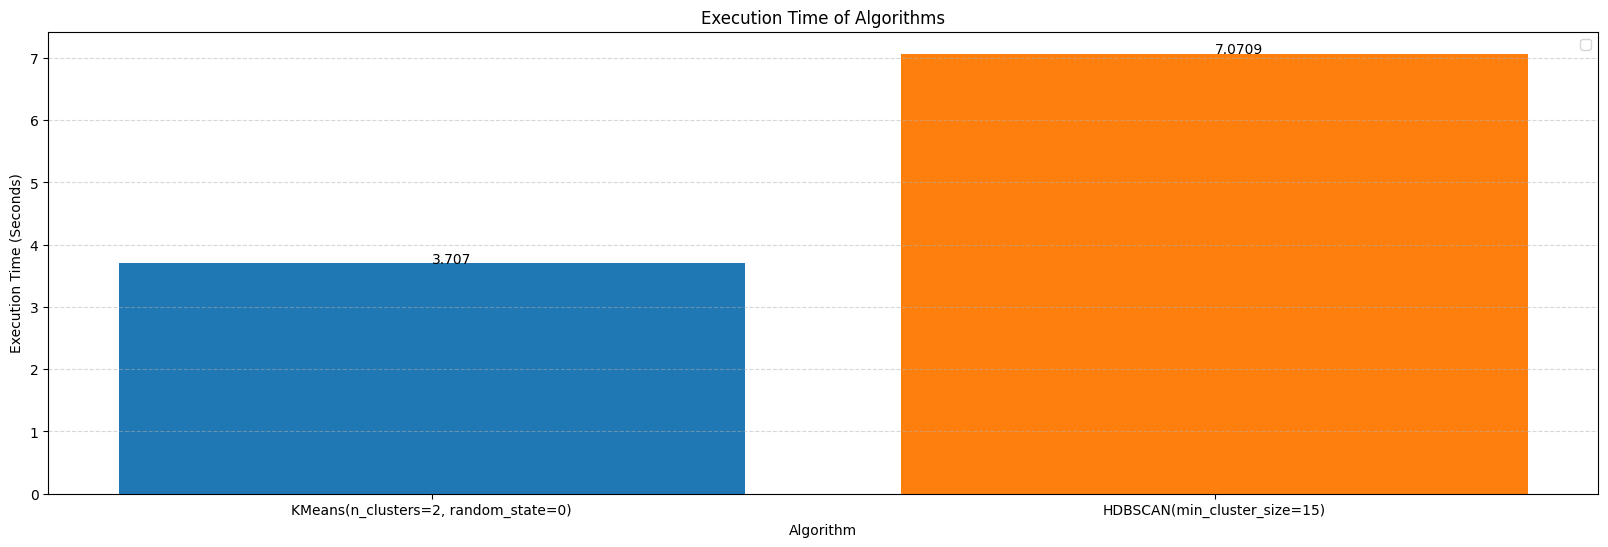

In [23]:

# time - algorithm computational cost
df_algorithms_execution_time = []
for item in best_models:
    df_algorithms_execution_time.append({'Algorithm':best_models[item]['name'],'Time':best_models[item]['execution_time']})
df_algorithms_execution_time=pd.DataFrame(df_algorithms_execution_time)
# Plotting
plt.figure(figsize=(20, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

plt.bar(df_algorithms_execution_time['Algorithm'], df_algorithms_execution_time['Time'], color=colors)

plt.grid(axis='y', linestyle='--', alpha=0.5)
for i in range(len(df_algorithms_execution_time['Algorithm'])):
        plt.text(i,round(df_algorithms_execution_time['Time'][i],4),round(df_algorithms_execution_time['Time'][i],4))
plt.title('Execution Time of Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Execution Time (Seconds)')
plt.legend( )

#plt.show()


In [24]:
print(best_models)

{'KMeans': {'model': KMeans(n_clusters=2, random_state=0), 'name': 'KMeans(n_clusters=2, random_state=0)', 'auroc': 1.0, 'params': {'n_clusters': 2}, 'y_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=int32), 'y_true': array([0, 0, 0, ..., 0, 0, 0]), 'scores': array([0, 0, 0, ..., 0, 0, 0]), 'FP': ['52.21.113.142', '184.26.44.98', '23.208.96.93', '119.167.164.12', '164.132.124.97', '165.224.212.35', '166.78.109.115', '8.253.104.136', '52.84.26.87', '54.192.36.81', '104.25.186.115', '192.229.163.180', '54.209.102.237', '115.127.226.222', '81.19.94.174', '8.247.84.128', '23.208.71.202', '77.158.24.250', '212.42.76.247', '23.45.197.60', '54.192.37.26', '93.158.134.90', '14.0.67.53', '158.85.42.53', '202.39.235.195', '54.183.252.153', '54.243.242.36', '178.248.237.16', '104.97.112.80', '43.253.238.186', '52.84.145.42', '52.84.33.25', '208.111.171.216', '213.19.161.155', '23.34.190.114', '23.203.81.209', '116.62.80.182', '185.13.208.24', '46.51.247.29', '151.101.45.209', '60.199.243.53', '69.90

In [25]:
print("Execution time comparation table of all algorithms:")

print(df_algorithms_execution_time)

Execution time comparation table of all algorithms:
                              Algorithm      Time
0  KMeans(n_clusters=2, random_state=0)  3.707023
1          HDBSCAN(min_cluster_size=15)  7.070892


/tmp/ipykernel_118300/228349247.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend( )


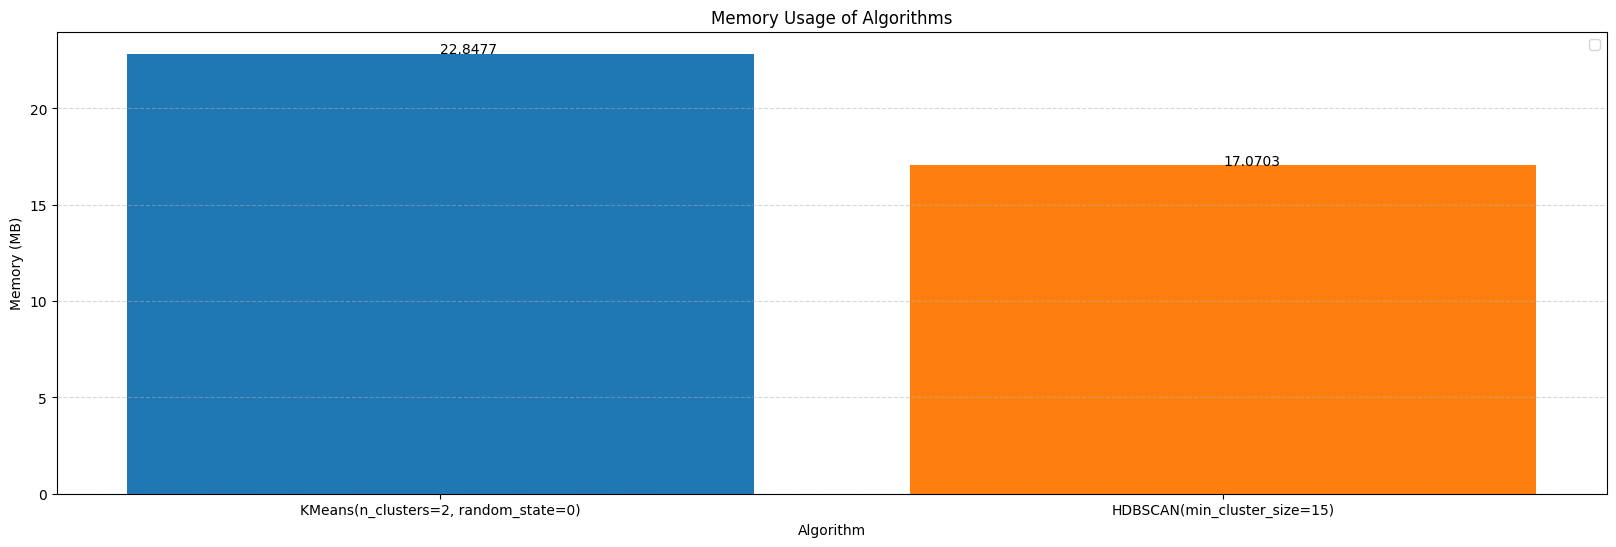

In [26]:

# memory_usage - algorithm computational cost
df_algorithms_memory_time = []
for item in best_models:
    df_algorithms_memory_time.append({'Algorithm':best_models[item]['name'],'Memory':best_models[item]['memory_usage']})
df_algorithms_memory_time=pd.DataFrame(df_algorithms_memory_time)
# Plotting
plt.figure(figsize=(20, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

plt.bar(df_algorithms_memory_time['Algorithm'], df_algorithms_memory_time['Memory'], color=colors)

plt.grid(axis='y', linestyle='--', alpha=0.5)
for i in range(len(df_algorithms_memory_time['Algorithm'])):
        plt.text(i,round(df_algorithms_memory_time['Memory'][i],4),round(df_algorithms_memory_time['Memory'][i],4))
plt.title('Memory Usage of Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Memory (MB)')
plt.legend( )
#plt.show()



In [27]:
print("Memory Usage comparation table of all algorithms:")

print(df_algorithms_memory_time)

Memory Usage comparation table of all algorithms:
                              Algorithm     Memory
0  KMeans(n_clusters=2, random_state=0)  22.847656
1          HDBSCAN(min_cluster_size=15)  17.070312


/tmp/ipykernel_118300/3836140517.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend( )


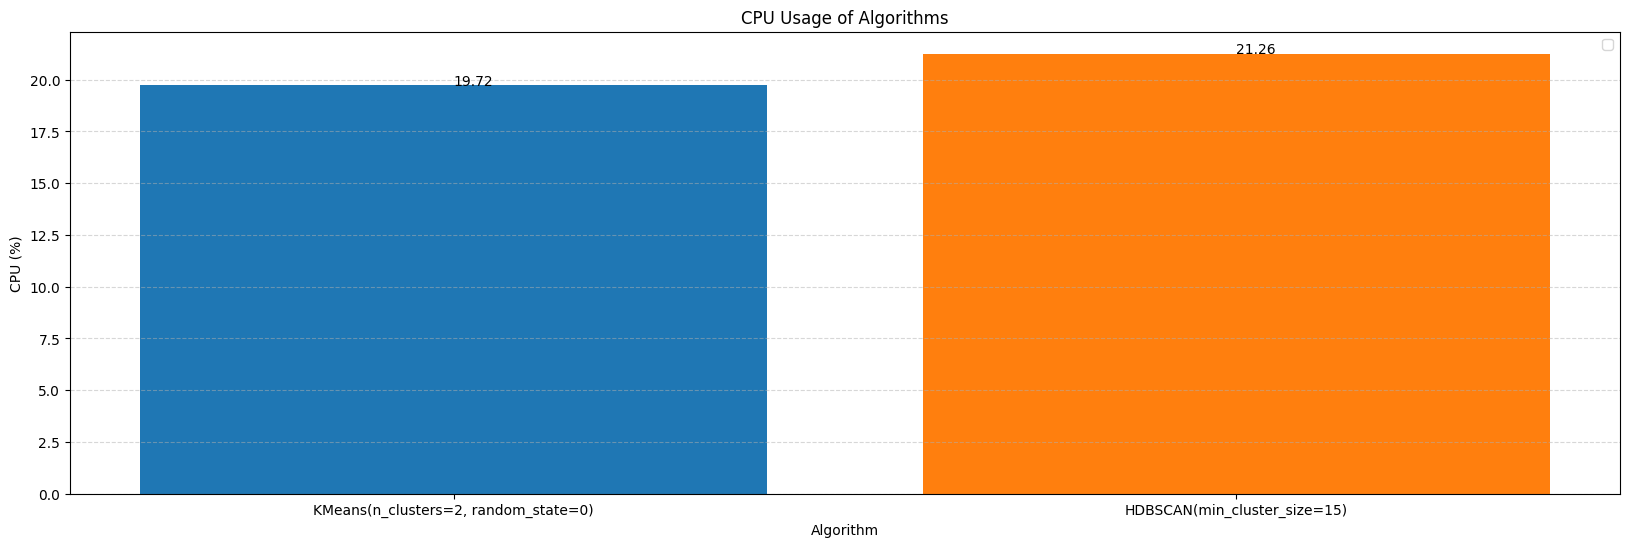

In [28]:

# memory_usage - algorithm computational cost
df_algorithms_cpu_usage = []
for item in best_models:
    df_algorithms_cpu_usage.append({'Algorithm':best_models[item]['name'],'CPU':best_models[item]['cpu_time_user']})
df_algorithms_cpu_usage=pd.DataFrame(df_algorithms_cpu_usage)
# Plotting
plt.figure(figsize=(20, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

plt.bar(df_algorithms_cpu_usage['Algorithm'], df_algorithms_cpu_usage['CPU'], color=colors)

plt.grid(axis='y', linestyle='--', alpha=0.5)
for i in range(len(df_algorithms_cpu_usage['Algorithm'])):
        plt.text(i,round(df_algorithms_cpu_usage['CPU'][i],4),round(df_algorithms_cpu_usage['CPU'][i],4))
plt.title('CPU Usage of Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('CPU (%)')
plt.legend( )
#plt.show()



In [29]:
print("CPU Usage comparation table of all algorithms:")
print(df_algorithms_cpu_usage)

CPU Usage comparation table of all algorithms:
                              Algorithm    CPU
0  KMeans(n_clusters=2, random_state=0)  19.72
1          HDBSCAN(min_cluster_size=15)  21.26


ROC_AUC omparation table of all algorithms:
            ROAUC
KMeans   1.000000
HDBSCAN  0.814301


/tmp/ipykernel_118300/1374185679.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text( i,round(roc_auc_table['ROAUC'][i],3),str(round(roc_auc_table['ROAUC'][i]*100,3))+'%')


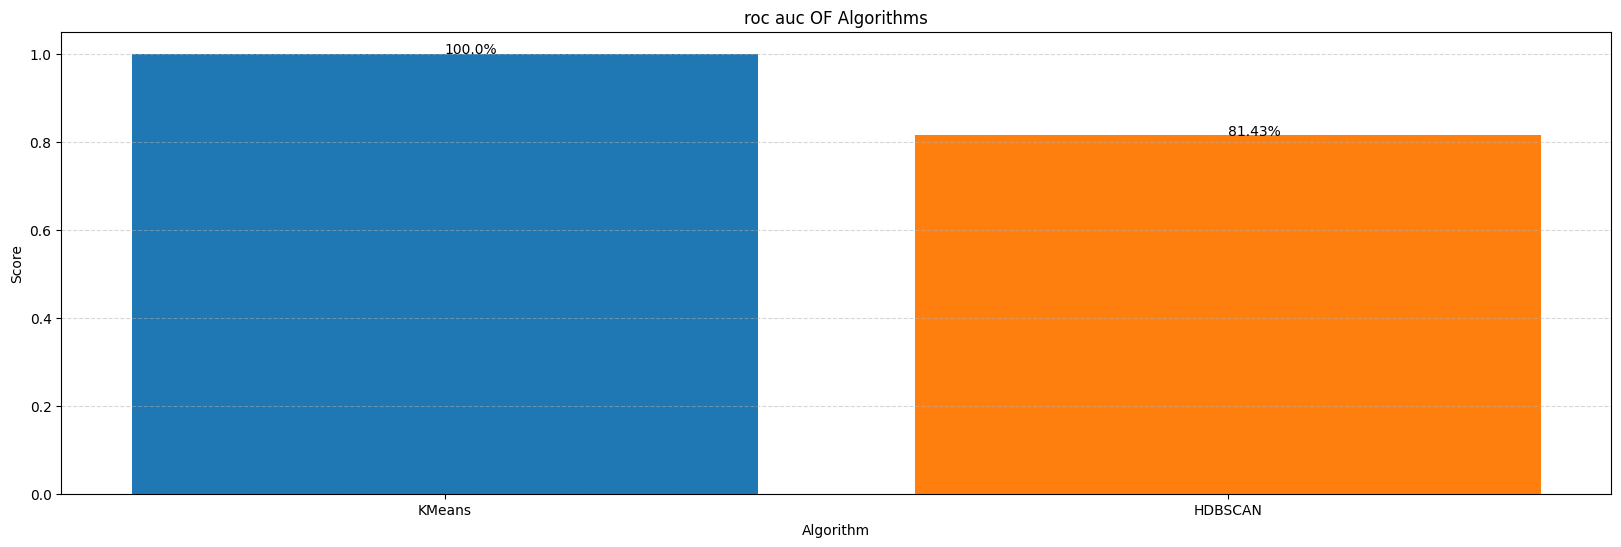

In [30]:
roc_auc_table = pd.DataFrame.from_dict(roc_auc_scores, orient='index', columns=['ROAUC'])
print("ROC_AUC omparation table of all algorithms:")
print(roc_auc_table)


# Plotting
plt.figure(figsize=(20, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

plt.bar(roc_auc_table.index,roc_auc_table['ROAUC'], color=colors)

plt.grid(axis='y', linestyle='--', alpha=0.5)
for i in range(len(roc_auc_table.index)):
        plt.text( i,round(roc_auc_table['ROAUC'][i],3),str(round(roc_auc_table['ROAUC'][i]*100,3))+'%')
plt.title('roc auc OF Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Score')
 

plt.show()


In [31]:

# Plot ROC curve and confusion matrix for the best model
best_model_name = roc_auc_table['ROAUC'].idxmax()
best_model = models[best_model_name]

print("Best Model is:",str(best_model))

Best Model is: KMeans(random_state=0)


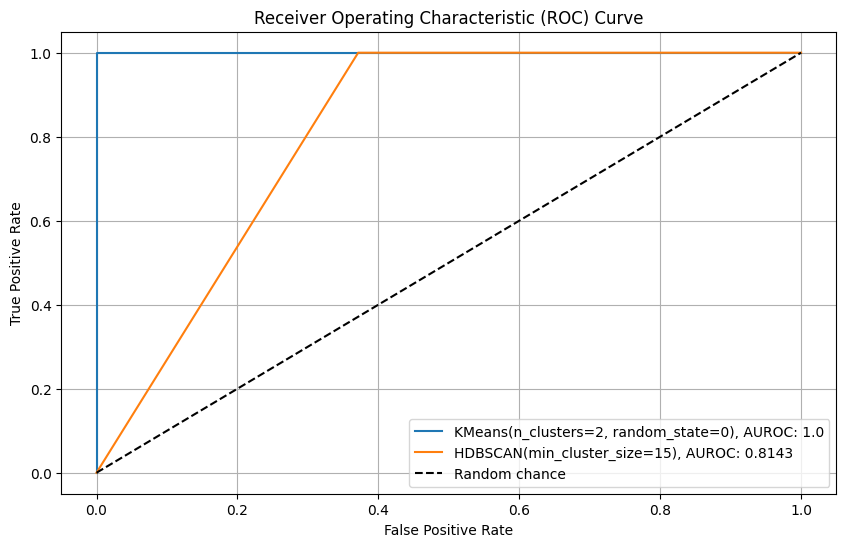

In [32]:
# Receiver Operating Characteristic (ROC) Curve

plt.figure(figsize=(10, 6))
for name in best_models:
    val=best_models[name]
    model=val['model']
    y_scores=val['scores']
    y_pred=val['y_pred']
    y_true=val['y_true']
    auroc=val['auroc']
    #auroc, y_scores, y_true,y_pred = calculate_roc_auc(model, X_pca, df_base[cols])
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    plt.plot(fpr, tpr, label=str(model)+", AUROC: "+str(round(auroc,5)))
plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='best')
plt.grid()
plt.show()


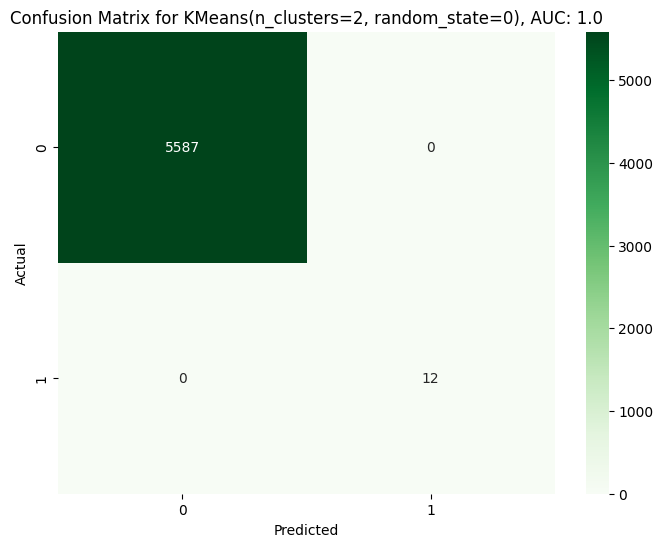

In [33]:

plt.figure(figsize=(8, 6))
# Plot confusion matrix
#for name in best_models:
val=best_models[best_model_name]
model=val['model']
y_scores=val['scores']
y_pred=val['y_pred']
y_true=val['y_true']
auroc=val['auroc']
# Plot ROC Curve
threshold = 0.5
y_pred_binary = (y_scores >= threshold).astype(int)
cm = confusion_matrix(y_true, y_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for ' + str(model)+", AUC: "+ str(round(auroc,5)))
plt.show()


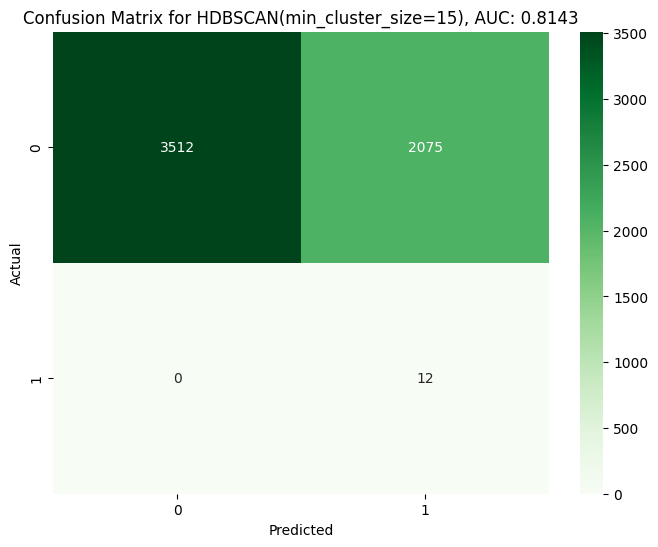

In [34]:

plt.figure(figsize=(8, 6))
# Plot confusion matrix
#for name in best_models:
val=best_models['HDBSCAN']
model=val['model']
y_scores=val['scores']
y_pred=val['y_pred']
y_true=val['y_true']
auroc=val['auroc']
# Plot ROC Curve
threshold = 0.5
y_pred_binary = (y_scores >= threshold).astype(int)
cm = confusion_matrix(y_true, y_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for ' + str(model)+", AUC: "+ str(round(auroc,5)))
plt.show()
